<a href="https://colab.research.google.com/github/Davi2B/Python/blob/main/biblioteca_de_vendas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== DADOS DE VENDAS ==========
    id_venda  data_venda    produto    categoria  valor_venda
0          1  2023-01-01  Produto A  Eletrônicos       1500.0
1          2  2023-01-05  Produto B       Roupas        350.0
2          3  2023-02-10  Produto C  Eletrônicos       1200.0
3          4  2023-03-15  Produto D       Livros        200.0
4          5  2023-03-20  Produto E  Eletrônicos        800.0
5          6  2023-04-02  Produto F       Roupas        400.0
6          7  2023-05-05  Produto G       Livros        150.0
7          8  2023-06-10  Produto H  Eletrônicos       1000.0
8          9  2023-07-20  Produto I       Roupas        600.0
9         10  2023-08-25  Produto J  Eletrônicos        700.0
10        11  2023-09-30  Produto K       Livros        300.0
11        12  2023-10-05  Produto L       Roupas        450.0
12        13  2023-11-15  Produto M  Eletrônicos        900.0
13        14  2023-12-20  Produto N       Livros        250.0

          RELATÓRIO FINAL DE VE

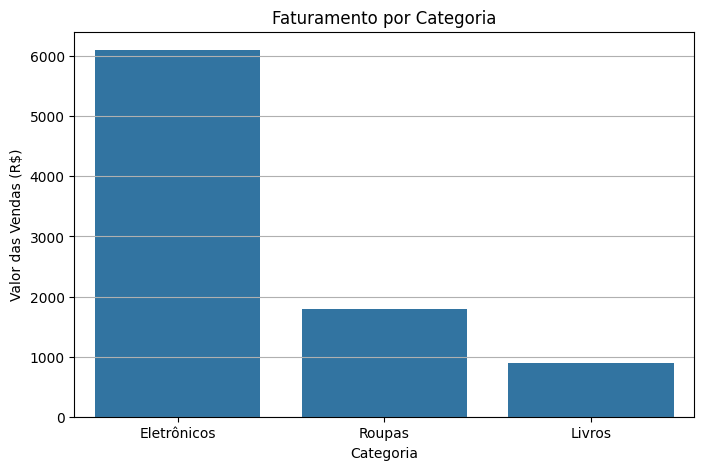

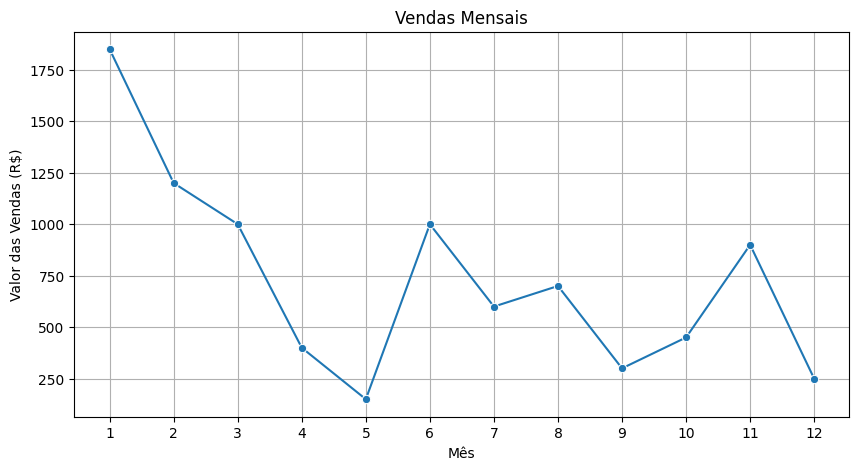

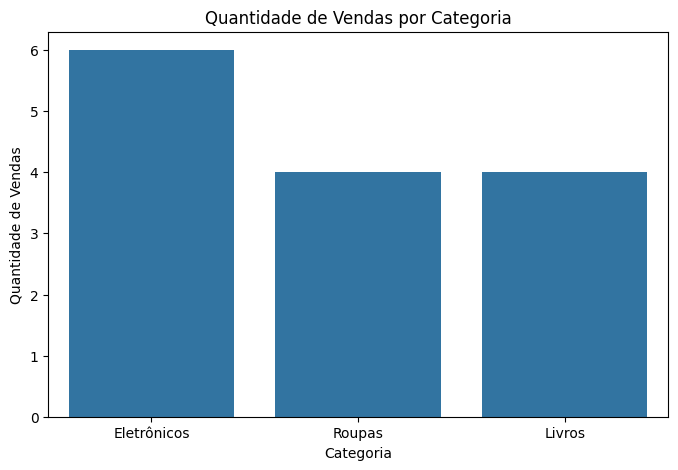


Banco de dados fechado com sucesso!


In [ ]:
# ============================================================
# ATIVIDADE 1 - MELHORAR O DESEMPENHO DE VENDAS
# ============================================================

# 1. IMPORTAÇÃO DAS BIBLIOTECAS
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 2. CONEXÃO COM O BANCO DE DADOS SQLITE
# ============================================================

# Cria ou conecta ao banco de dados
conexao = sqlite3.connect('dados_vendas.db')

# Cria o cursor para executar comandos SQL
cursor = conexao.cursor()


# ============================================================
# 3. CRIAÇÃO DA TABELA
# ============================================================

cursor.execute('''
CREATE TABLE IF NOT EXISTS vendas1 (
    id_venda INTEGER PRIMARY KEY AUTOINCREMENT,
    data_venda DATE,
    produto TEXT,
    categoria TEXT,
    valor_venda REAL
)
''')


# ============================================================
# 4. INSERÇÃO DOS DADOS
# ============================================================

# Limpa os dados anteriores para evitar duplicação
cursor.execute("DELETE FROM vendas1")

# Insere os dados de vendas
cursor.execute('''
INSERT INTO vendas1
(data_venda, produto, categoria, valor_venda)
VALUES
('2023-01-01', 'Produto A', 'Eletrônicos', 1500.00),
('2023-01-05', 'Produto B', 'Roupas', 350.00),
('2023-02-10', 'Produto C', 'Eletrônicos', 1200.00),
('2023-03-15', 'Produto D', 'Livros', 200.00),
('2023-03-20', 'Produto E', 'Eletrônicos', 800.00),
('2023-04-02', 'Produto F', 'Roupas', 400.00),
('2023-05-05', 'Produto G', 'Livros', 150.00),
('2023-06-10', 'Produto H', 'Eletrônicos', 1000.00),
('2023-07-20', 'Produto I', 'Roupas', 600.00),
('2023-08-25', 'Produto J', 'Eletrônicos', 700.00),
('2023-09-30', 'Produto K', 'Livros', 300.00),
('2023-10-05', 'Produto L', 'Roupas', 450.00),
('2023-11-15', 'Produto M', 'Eletrônicos', 900.00),
('2023-12-20', 'Produto N', 'Livros', 250.00)
''')

# Salva as alterações
conexao.commit()


# ============================================================
# 5. CARREGAMENTO DOS DADOS COM PANDAS
# ============================================================

# Consulta os dados da tabela
consulta = "SELECT * FROM vendas1"

# Carrega os dados para um DataFrame
df_vendas = pd.read_sql_query(consulta, conexao)

# Exibe os dados
print("========== DADOS DE VENDAS ==========")
print(df_vendas)


# ============================================================
# 6. PREPARAÇÃO DOS DADOS
# ============================================================

# Converte a coluna de data para o formato datetime
df_vendas['data_venda'] = pd.to_datetime(df_vendas['data_venda'])

# Cria uma coluna contendo o mês da venda
df_vendas['mes'] = df_vendas['data_venda'].dt.month


# ============================================================
# 7. ANÁLISE DOS DADOS
# ============================================================

# Calcula o total de vendas
total_vendas = df_vendas['valor_venda'].sum()

# Calcula a média das vendas
media_vendas = df_vendas['valor_venda'].mean()

# Identifica a maior venda
maior_venda = df_vendas['valor_venda'].max()

# Identifica a menor venda
menor_venda = df_vendas['valor_venda'].min()


# ============================================================
# 8. FATURAMENTO POR CATEGORIA
# ============================================================

vendas_categoria = (
    df_vendas
    .groupby('categoria')['valor_venda']
    .sum()
    .sort_values(ascending=False)
)


# ============================================================
# 9. VENDAS POR MÊS
# ============================================================

vendas_mes = (
    df_vendas
    .groupby('mes')['valor_venda']
    .sum()
)


# ============================================================
# 10. QUANTIDADE DE VENDAS POR CATEGORIA
# ============================================================

quantidade_categoria = df_vendas['categoria'].value_counts()


# ============================================================
# 11. EXIBIÇÃO DO RELATÓRIO FINAL
# ============================================================

print("\n==========================================")
print("          RELATÓRIO FINAL DE VENDAS")
print("==========================================")

print(f"Total de vendas: R$ {total_vendas:.2f}")
print(f"Média por venda: R$ {media_vendas:.2f}")
print(f"Maior venda: R$ {maior_venda:.2f}")
print(f"Menor venda: R$ {menor_venda:.2f}")

print("\n--- FATURAMENTO POR CATEGORIA ---")
print(vendas_categoria)

print("\n--- QUANTIDADE DE VENDAS POR CATEGORIA ---")
print(quantidade_categoria)

print("\n--- VENDAS POR MÊS ---")
print(vendas_mes)

print("\nCategoria com maior faturamento:")
print(vendas_categoria.idxmax())

print("==========================================")


# ============================================================
# 12. GRÁFICO - FATURAMENTO POR CATEGORIA
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    x=vendas_categoria.index,
    y=vendas_categoria.values
)

plt.title('Faturamento por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Valor das Vendas (R$)')
plt.grid(axis='y')

plt.show()


# ============================================================
# 13. GRÁFICO - VENDAS MENSAIS
# ============================================================

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=vendas_mes.index,
    y=vendas_mes.values,
    marker='o'
)

plt.title('Vendas Mensais')
plt.xlabel('Mês')
plt.ylabel('Valor das Vendas (R$)')
plt.xticks(range(1, 13))
plt.grid()

plt.show()


# ============================================================
# 14. GRÁFICO - QUANTIDADE DE VENDAS POR CATEGORIA
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_vendas,
    x='categoria'
)

plt.title('Quantidade de Vendas por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Quantidade de Vendas')

plt.show()


# ============================================================
# 15. FECHAMENTO DO BANCO DE DADOS
# ============================================================

conexao.close()

print("\nBanco de dados fechado com sucesso!")